### Imports:

In [38]:
# %matplotlib widget
# %matplotlib inline 
import os
import pandas as pd
import vis_detect_helpers_v9 as hp
import photom_helpers as ph
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import vis_detect_helpers_v8 as hp2

In [4]:
import numpy as np
print(np.__version__)

1.26.4


### Load and/or preprocess raw data into dataframe:

### Create pkl file for each session according to directory and mouse id. pkl files are created in the folder 'preprocessed'. Also creates a pkl file for all the sessions from a given mouse.

In [3]:
BG_012 = hp.load_pickle('BG_012_allsession_data.pkl')
# BG_013 = hp.load_pickle('BG_013_allsession_data.pkl')
# BG_016 = hp.load_pickle('BG_016_allsession_data.pkl')
# BG_018 = hp.load_pickle('BG_018_allsession_data.pkl')
# BG_019 = hp.load_pickle('./photom_data/BG_019/preprocessed/prot4_sessions_data_BG_019.pkl')
# BG_020 = hp.load_pickle('./photom_data/BG_020/preprocessed/prot4_sessions_data_BG_020.pkl')
# BG_027 = hp.load_pickle('BG_027_allsession_data.pkl')
# BG_028 = hp.load_pickle('BG_028_allsession_data.pkl')
BG_021 = hp.load_pickle('G:/Postdoc_research/IntersectChr2/Data/raw/BG_021/allsession_data.pkl')

In [13]:
BG_021['change_category'] = BG_021['change_sizes_TF'].apply(hp.categorize_change_size)

In [36]:
all_mice_data.columns
columns_to_drop = ['baseline_on_timestamps', 'reference_start_actual',
       'reference_start_photometry', 'reference_start_error','reaction_time_Timestamps',
       'change_time_Timestamps','photometry_signals',
       'laser_states', 'dff_data', 'baseline_means', 'baseline_stds']

In [42]:
BG_021.drop('reaction_times_from_baseline', axis=1, inplace=True)

In [68]:
BG_012 = all_mice_data[all_mice_data['mouse_id'] == '012']
BG_013 = all_mice_data[all_mice_data['mouse_id'] == '013']
BG_016 = all_mice_data[all_mice_data['mouse_id'] == '016']
BG_018 = all_mice_data[all_mice_data['mouse_id'] == '018']
BG_019 = all_mice_data[all_mice_data['mouse_id'] == '019']
BG_020 = all_mice_data[all_mice_data['mouse_id'] == '020']
BG_021 = all_mice_data[all_mice_data['mouse_id'] == '021']
BG_027 = all_mice_data[all_mice_data['mouse_id'] == '027']
BG_028 = all_mice_data[all_mice_data['mouse_id'] == '028']

In [69]:
hp.save_as_pickle('BG_012_allsession_data.pkl',BG_012)
hp.save_as_pickle('BG_013_allsession_data.pkl',BG_013)
hp.save_as_pickle('BG_016_allsession_data.pkl',BG_016)
hp.save_as_pickle('BG_018_allsession_data.pkl',BG_018)
hp.save_as_pickle('BG_019_allsession_data.pkl',BG_019)
hp.save_as_pickle('BG_020_allsession_data.pkl',BG_020)
hp.save_as_pickle('BG_021_allsession_data.pkl',BG_021)
hp.save_as_pickle('BG_027_allsession_data.pkl',BG_027)
hp.save_as_pickle('BG_028_allsession_data.pkl',BG_028)

In [13]:
all_mice_behavior_only_df = hp.load_pickle('all_mice_behavior_only_df.pkl')

In [14]:
all_mice_behavior_only_df.reset_index(inplace=True, drop=True)

In [40]:
# Function to calculate 'reaction_times_from_baseline'
def calculate_reaction_times_from_baseline(row):
    if row['outcomes'] in ['Hit', 'Miss']:
        return row['reaction_times'] + row['change_times']
    else:
        return row['reaction_times']

# Apply the function to each row in the DataFrame
all_mice_behavior_only_df['reaction_times_from_baseline'] = all_mice_behavior_only_df.apply(calculate_reaction_times_from_baseline, axis=1)


In [41]:
all_mice_behavior_only_df

,mouse_id,session_date,session_time,session_timestamp,auto_rewd,punishment,protocol,iti_values,change_times,change_sizes_TF,outcomes,reaction_times,reaction_times_from_reference_start,TF_vectors,change_category,reaction_times_from_baseline
0,012,20231102,151200,2023-11-02 15:12:00,0,air_puff,4,3.511333,9.445,1.25,Hit,1.378,14.334333,"[0.92761753334287, 1.0611702363696316, 1.85909...",small,10.823
1,012,20231102,151200,2023-11-02 15:12:00,0,air_puff,4,3.416003,13.845,4.00,Hit,0.535,17.796003,"[1.144638356564254, 1.0791181105604692, 0.9845...",big,14.380
2,012,20231102,151200,2023-11-02 15:12:00,0,air_puff,4,3.142713,9.545,1.25,FA,8.621,11.763713,"[1.2801753494747972, 0.8565071592911024, 1.006...",small,8.621
3,012,20231102,151200,2023-11-02 15:12:00,0,air_puff,4,3.485343,6.745,1.25,FA,5.905,9.390343,"[0.9702992310290532, 1.3266709654806985, 0.790...",small,5.905
4,012,20231102,151200,2023-11-02 15:12:00,0,air_puff,4,3.606157,8.795,1.25,FA,8.365,11.971157,"[1.0704234277165363, 0.8588687642298977, 1.026...",small,8.365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255184,021,20241023,111757,2024-10-23 11:17:57,0,end_trial,4,3.248961,9.245,2.00,Hit,0.392,12.885961,"[1.0250267591838127, 1.1231042591992428, 0.964...",big,9.637
255185,021,20241023,111757,2024-10-23 11:17:57,0,end_trial,4,3.237556,7.295,4.00,Hit,0.382,10.914556,"[0.8013199073689782, 1.1119425326748982, 1.218...",big,7.677
255186,021,20241023,111757,2024-10-23 11:17:57,0,end_trial,4,3.034105,5.995,1.35,Miss,2.155,11.184105,"[0.9195590255339051, 1.226753188399298, 0.9857...",small,8.150
255187,021,20241023,111757,2024-10-23 11:17:57,0,end_trial,4,3.207165,6.145,2.00,Hit,0.584,9.936165,"[1.3881349548257453, 1.178118119903174, 0.8995...",big,6.729


In [ ]:
BG_012 = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'] == '012']
BG_013 = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'] == '013']
BG_016 = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'] == '016']
BG_018 = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'] == '018']
BG_019 = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'] == '019']
BG_020 = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'] == '020']
BG_021 = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'] == '021']
BG_027 = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'] == '027']
BG_028 = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'] == '028']

In [32]:
# Ensure 'outcomes' column exists and identify FA trials
session_data['is_fa'] = session_data['outcomes'] == 'FA'
session_data = session_data[session_data['reaction_times']>2]
# Calculate difference in trial indices to find consecutive trials (assuming index is properly ordered)
session_data['index_diff'] = session_data.index.to_series().diff().fillna(1)

# Flag the start of new FA sequences
session_data['new_fa_sequence'] = (session_data['is_fa'] & (session_data['index_diff'] != 1)) | (session_data['is_fa'] & session_data['is_fa'].shift(-1))

# Generate sequence IDs for consecutive FAs, cumsum() treats False as 0 and True as 1, so it increments the sum only at True
session_data['fa_sequence_id'] = session_data['new_fa_sequence'].cumsum()

# Keep rows with 'is_fa' == True and ensure they are part of a sequence with more than one 'FA'
counts = session_data[session_data['is_fa']]['fa_sequence_id'].value_counts()
valid_sequences = counts[counts > 1].index
fa_sequences = session_data[session_data['fa_sequence_id'].isin(valid_sequences)].copy()

In [14]:
sns.set_context('notebook')  # other options for context include paper (smaller), talk (bigger), and poster (biggest). Can also add 'scale' argument for axis text size
outcome_palette = {
    'Hit': 'green',
    'FA': 'red',
    'abort': 'black',
    'Miss': 'purple',
    'Ref': 'blue'
}

outcome_order = ['Hit', 'FA', 'Miss', 'abort', 'Ref']

laser_palette = {
    True: 'blue',
    False: 'gray'
}

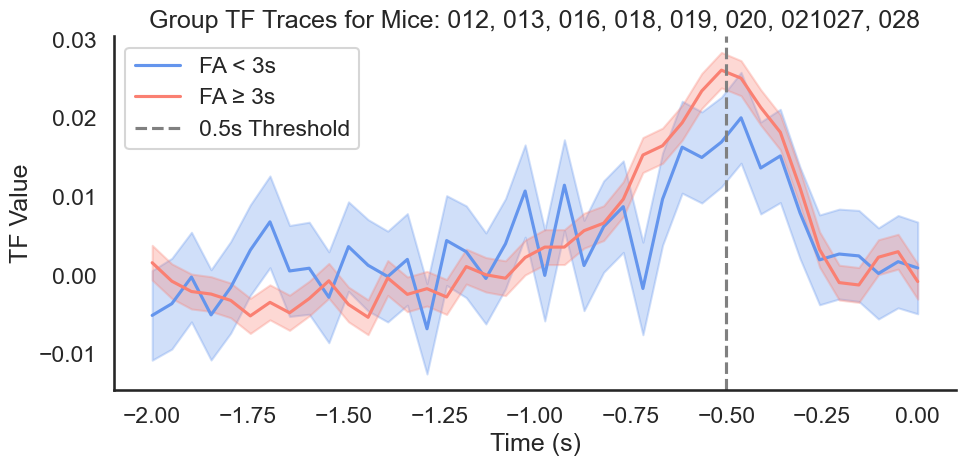

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='white')
sns.set_context('talk', font_scale=1.0)

# Define the subject groups based on mouse_id
subject_groups = [
    ['012','013', '016', '018', '019', '020','021' '027', '028']
    # Add more groups if needed
]

# Define reaction time thresholds
rt_threshold = 3.0
min_rt = 0.5  # Minimum reaction time after baseline onset

# Step 1: Loop through the subject groups
for group in subject_groups:
    # Initialize lists to hold windows for early and late FAs
    early_windows = []
    late_windows = []

    # Filter the DataFrame for the current group of mouse_ids
    group_df = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'].isin(group)]

    # Loop through each mouse in the group
    for mouse in group:
        mouse_df = group_df[group_df['mouse_id'] == mouse]

        # Get unique session identifiers (assuming 'session_timestamp' uniquely identifies a session)
        sessions = mouse_df['session_timestamp'].dropna().unique()

        for session in sessions:
            session_df = mouse_df[mouse_df['session_timestamp'] == session]

            # Step 2: Subset for the trials where the outcome was 'FA' and reaction_times >= min_rt
            fa_df = session_df[
                (session_df['outcomes'] == 'FA') & 
                (session_df['reaction_times'] >= min_rt)
            ]
            if fa_df.empty:
                continue

            # Ensure 'TF_vectors' column exists
            if 'TF_vectors' in fa_df.columns:
                tf_vectors = fa_df['TF_vectors'].tolist()
            else:
                print("Error: 'TF_vectors' column not found.")
                continue

            # Step 3: For each trial, extract the TF vector window
            expected_window_size = 40  # 2 seconds with 50ms per bin

            for rt, tf_vector in zip(fa_df['reaction_times'], tf_vectors):
                # Ensure tf_vector is a numpy array
                tf_vector = np.array(tf_vector)

                # Calculate bins such that we always get a window size of 2 seconds
                start_bin = max(0, int(np.floor((rt - 2.0) * 20)))  # 50ms bins => 20 bins per second
                end_bin = start_bin + expected_window_size  # Ensure window size

                window = np.log2(tf_vector[start_bin:end_bin])

                if len(window) == expected_window_size:
                    if rt < rt_threshold:
                        early_windows.append(window)
                    else:
                        late_windows.append(window)
                else:
                    print(f"Warning: unexpected window size for trial {rt}, the bin window size is {len(window)}")

    # Step 4: Create a single plot for the group
    fig, ax = plt.subplots(figsize=(10, 5))
    
    time_points = np.linspace(-2, 0, expected_window_size)
    
    # Plot Early FAs
    if early_windows:
        mean_early = np.mean(early_windows, axis=0)
        ci95_early = 1.96 * np.std(early_windows, axis=0) / np.sqrt(len(early_windows))
        ax.plot(time_points, mean_early, color='cornflowerblue', label='FA < 3s')
        ax.fill_between(time_points, mean_early - ci95_early, mean_early + ci95_early, color='cornflowerblue', alpha=0.3)
    
    # Plot Late FAs
    if late_windows:
        mean_late = np.mean(late_windows, axis=0)
        ci95_late = 1.96 * np.std(late_windows, axis=0) / np.sqrt(len(late_windows))
        ax.plot(time_points, mean_late, color='salmon', label='FA ≥ 3s')
        ax.fill_between(time_points, mean_late - ci95_late, mean_late + ci95_late, color='salmon', alpha=0.3)
    
    # Add a vertical line at 0.5 seconds to indicate the minimum reaction time
    ax.axvline(x=-0.5, color='gray', linestyle='--', label='0.5s Threshold')
    
    ax.set_title(f"Group TF Traces for Mice: {', '.join(group)}")
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('TF Value')
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

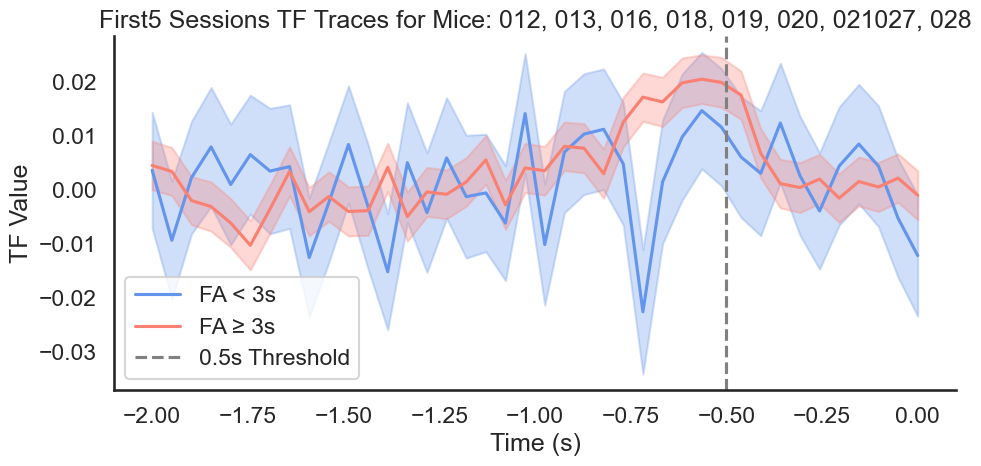

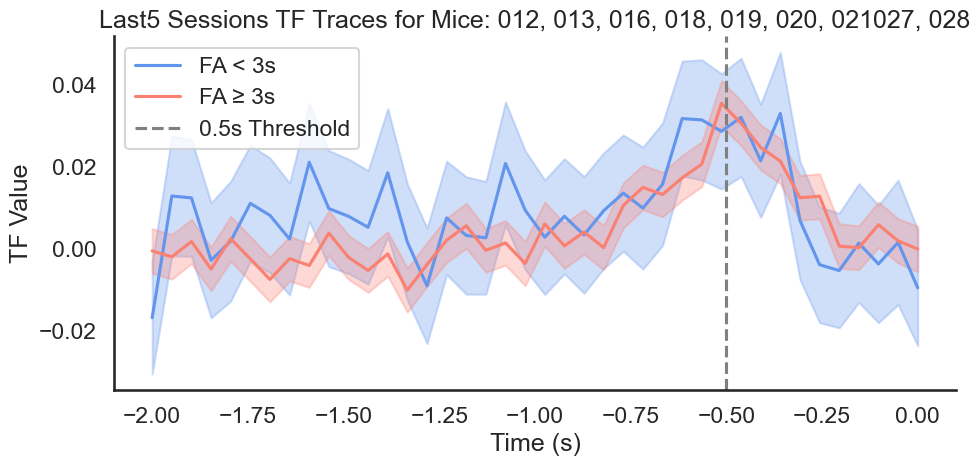

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='white')
sns.set_context('talk', font_scale=1.0)

# Define the subject groups based on mouse_id
subject_groups = [
    ['012','013', '016', '018', '019', '020','021' '027', '028']
    # Add more groups if needed
]

# Define reaction time thresholds
rt_threshold = 3.0
min_rt = 0.25  # Minimum reaction time after baseline onset

# Step 1: Loop through the subject groups
for group in subject_groups:
    # Initialize dictionaries to hold windows for session subsets
    windows_data = {
        'first5_early': [],
        'first5_late': [],
        'last5_early': [],
        'last5_late': []
    }

    # Filter the DataFrame for the current group of mouse_ids
    group_df = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'].isin(group)]

    # Loop through each mouse in the group
    for mouse in group:
        mouse_df = group_df[group_df['mouse_id'] == mouse]

        # Get unique session identifiers sorted chronologically
        sessions = sorted(mouse_df['session_timestamp'].dropna().unique())

        # Select first 5 and last 5 sessions
        first5_sessions = sessions[:5]
        last5_sessions = sessions[-5:]

        # Function to process sessions
        def process_sessions(session_list, window_key_prefix):
            for session in session_list:
                session_df = mouse_df[mouse_df['session_timestamp'] == session]

                # Step 2: Subset for the trials where the outcome was 'FA' and reaction_times >= min_rt
                fa_df = session_df[
                    (session_df['outcomes'] == 'FA') & 
                    (session_df['reaction_times'] >= min_rt)
                ]
                if fa_df.empty:
                    continue

                # Ensure 'TF_vectors' column exists
                if 'TF_vectors' in fa_df.columns:
                    tf_vectors = fa_df['TF_vectors'].tolist()
                else:
                    print("Error: 'TF_vectors' column not found.")
                    continue

                # Step 3: For each trial, extract the TF vector window
                expected_window_size = 40  # 2 seconds with 50ms per bin

                for rt, tf_vector in zip(fa_df['reaction_times'], tf_vectors):
                    # Ensure tf_vector is a numpy array
                    tf_vector = np.array(tf_vector)

                    # Calculate bins such that we always get a window size of 2 seconds
                    start_bin = max(0, int(np.floor((rt - 2) * 20)))  # 50ms bins => 20 bins per second
                    end_bin = start_bin + expected_window_size  # Ensure window size

                    window = np.log2(tf_vector[start_bin:end_bin])

                    if len(window) == expected_window_size:
                        if rt < rt_threshold:
                            windows_data[f'{window_key_prefix}_early'].append(window)
                        else:
                            windows_data[f'{window_key_prefix}_late'].append(window)
                    else:
                        print(f"Warning: unexpected window size for trial {rt}, the bin window size is {len(window)}")

        # Process first 5 sessions
        process_sessions(first5_sessions, 'first5')

        # Process last 5 sessions
        process_sessions(last5_sessions, 'last5')

    # Step 4: Create separate plots for first5 and last5 sessions
    for session_subset in ['first5', 'last5']:
        fig, ax = plt.subplots(figsize=(10, 5))
        
        time_points = np.linspace(-2, 0, expected_window_size)
        
        # Plot Early FAs
        early_key = f'{session_subset}_early'
        if windows_data[early_key]:
            mean_early = np.mean(windows_data[early_key], axis=0)
            ci95_early = 1.96 * np.std(windows_data[early_key], axis=0) / np.sqrt(len(windows_data[early_key]))
            ax.plot(time_points, mean_early, color='cornflowerblue', label='FA < 3s')
            ax.fill_between(time_points, mean_early - ci95_early, mean_early + ci95_early, color='cornflowerblue', alpha=0.3)
        
        # Plot Late FAs
        late_key = f'{session_subset}_late'
        if windows_data[late_key]:
            mean_late = np.mean(windows_data[late_key], axis=0)
            ci95_late = 1.96 * np.std(windows_data[late_key], axis=0) / np.sqrt(len(windows_data[late_key]))
            ax.plot(time_points, mean_late, color='salmon', label='FA ≥ 3s')
            ax.fill_between(time_points, mean_late - ci95_late, mean_late + ci95_late, color='salmon', alpha=0.3)
        
        # Add a vertical line at -0.5 seconds to indicate the minimum reaction time
        ax.axvline(x=-0.5, color='gray', linestyle='--', label='0.5s Threshold')
        
        ax.set_title(f"{session_subset.capitalize()} Sessions TF Traces for Mice: {', '.join(group)}")
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('TF Value')
        ax.legend()
        sns.despine()
        plt.tight_layout()
        plt.show()

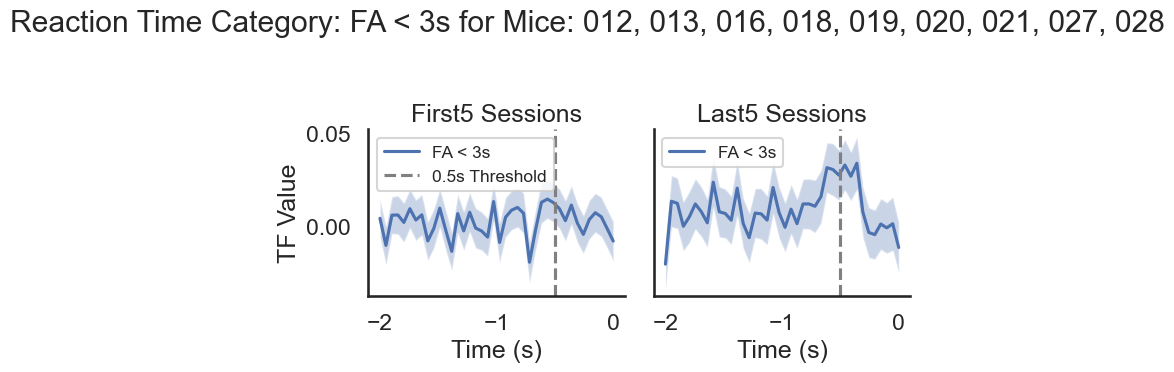

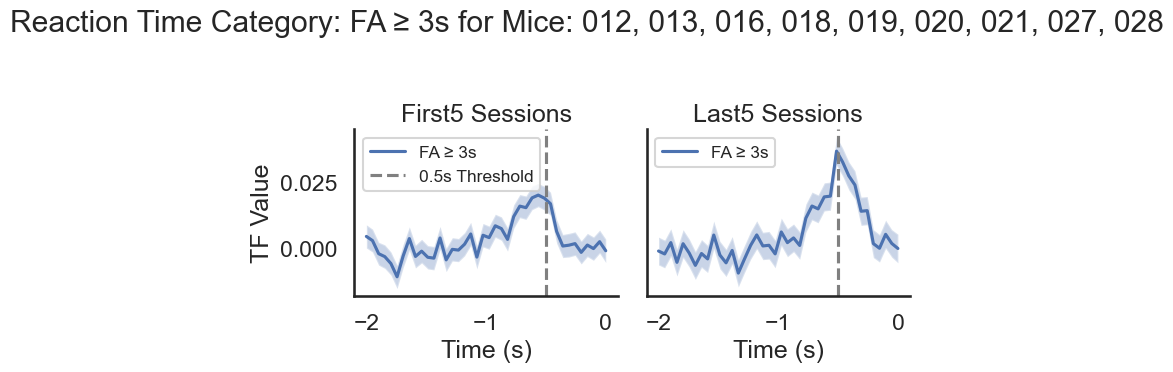

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='white')
sns.set_context('talk', font_scale=1.0)

# Define the subject groups based on mouse_id
subject_groups = [
    ['012','013', '016', '018', '019', '020','021' ,'027', '028']
    # Add more groups if needed
]

# Define reaction time thresholds
rt_threshold = 3.0
min_rt = 0.5 # Minimum reaction time after baseline onset

# Step 1: Loop through the subject groups
for group in subject_groups:
    # Initialize dictionaries to hold windows for session subsets
    windows_data = {
        'first5_early': [],
        'first5_late': [],
        'last5_early': [],
        'last5_late': []
    }

    # Filter the DataFrame for the current group of mouse_ids
    group_df = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'].isin(group)]

    # Loop through each mouse in the group
    for mouse in group:
        mouse_df = group_df[group_df['mouse_id'] == mouse]

        # Get unique session identifiers sorted chronologically
        sessions = sorted(mouse_df['session_timestamp'].dropna().unique())

        # Select first 5 and last 5 sessions
        first5_sessions = sessions[:5]
        last5_sessions = sessions[-5:]

        # Function to process sessions
        def process_sessions(session_list, window_key_prefix):
            for session in session_list:
                session_df = mouse_df[mouse_df['session_timestamp'] == session]

                # Step 2: Subset for the trials where the outcome was 'FA' and reaction_times >= min_rt
                fa_df = session_df[
                    (session_df['outcomes'] == 'FA') & 
                    (session_df['reaction_times'] >= min_rt)
                ]
                if fa_df.empty:
                    continue

                # Ensure 'TF_vectors' column exists
                if 'TF_vectors' in fa_df.columns:
                    tf_vectors = fa_df['TF_vectors'].tolist()
                else:
                    print("Error: 'TF_vectors' column not found.")
                    continue

                # Step 3: For each trial, extract the TF vector window
                expected_window_size = 40  # 2 seconds with 50ms per bin

                for rt, tf_vector in zip(fa_df['reaction_times'], tf_vectors):
                    # Ensure tf_vector is a numpy array
                    tf_vector = np.array(tf_vector)

                    # Calculate bins such that we always get a window size of 2 seconds
                    start_bin = max(0, int(np.floor((rt - 2) * 20)))  # 50ms bins => 20 bins per second
                    end_bin = start_bin + expected_window_size  # Ensure window size

                    window = np.log2(tf_vector[start_bin:end_bin])

                    if len(window) == expected_window_size:
                        if rt < rt_threshold:
                            windows_data[f'{window_key_prefix}_early'].append(window)
                        else:
                            windows_data[f'{window_key_prefix}_late'].append(window)
                    else:
                        print(f"Warning: unexpected window size for trial {rt}, the bin window size is {len(window)}")

        # Process first 5 sessions
        process_sessions(first5_sessions, 'first5')

        # Process last 5 sessions
        process_sessions(last5_sessions, 'last5')

    # Step 4: Create combined plots
    for rt_category, rt_label in zip(['early', 'late'], ['FA < 3s', 'FA ≥ 3s']):
        fig, axs = plt.subplots(1, 2, figsize=(7, 4), sharey=True)

        time_points = np.linspace(-2, 0, expected_window_size)

        for idx, session_subset in enumerate(['first5', 'last5']):
            key = f'{session_subset}_{rt_category}'
            if windows_data[key]:
                mean = np.mean(windows_data[key], axis=0)
                ci95 = 1.96 * np.std(windows_data[key], axis=0) / np.sqrt(len(windows_data[key]))
                axs[idx].plot(time_points, mean, label=rt_label)
                axs[idx].fill_between(time_points, mean - ci95, mean + ci95, alpha=0.3)

            axs[idx].axvline(x=-0.5, color='gray', linestyle='--', label='0.5s Threshold' if session_subset == 'first5' else "")
            axs[idx].set_title(f"{session_subset.capitalize()} Sessions")
            axs[idx].set_xlabel('Time (s)')
            if idx == 0:
                axs[idx].set_ylabel('TF Value')
            axs[idx].legend(fontsize = 'x-small')

        plt.suptitle(f"Reaction Time Category: {rt_label} for Mice: {', '.join(group)}")
        sns.despine()
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

Number of events for First5 Sessions, FA < 3s: 2099
Number of events for First5 Sessions, FA ≥ 3s: 12320
Number of events for Last5 Sessions, FA < 3s: 1281
Number of events for Last5 Sessions, FA ≥ 3s: 8640


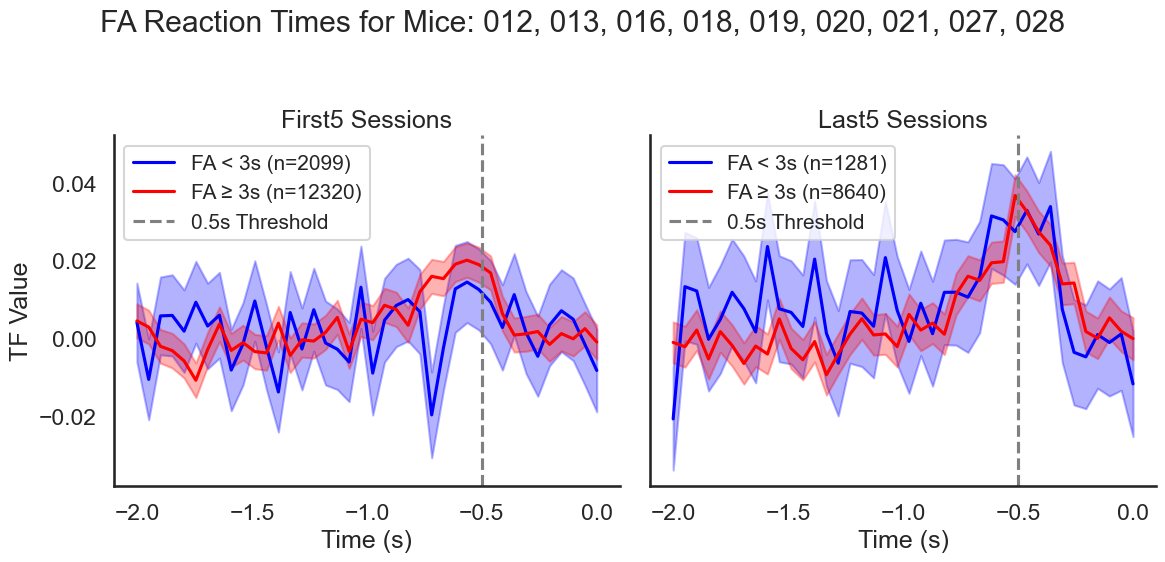

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='white')
sns.set_context('talk', font_scale=1.0)

# Define the subject groups based on mouse_id
subject_groups = [
    ['012', '013', '016', '018', '019', '020', '021', '027', '028']
    # Add more groups if needed
]

# Define reaction time thresholds
rt_threshold = 3.0
min_rt = 0.5  # Minimum reaction time after baseline onset

# Step 1: Loop through the subject groups
for group in subject_groups:
    # Initialize dictionaries to hold windows for session subsets
    windows_data = {
        'first5_early': [],
        'first5_late': [],
        'last5_early': [],
        'last5_late': []
    }

    # Filter the DataFrame for the current group of mouse_ids
    group_df = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'].isin(group)]

    # Loop through each mouse in the group
    for mouse in group:
        mouse_df = group_df[group_df['mouse_id'] == mouse]

        # Get unique session identifiers sorted chronologically
        sessions = sorted(mouse_df['session_timestamp'].dropna().unique())

        # Select first 5 and last 5 sessions
        first5_sessions = sessions[:5]
        last5_sessions = sessions[-5:]

        # Function to process sessions
        def process_sessions(session_list, window_key_prefix):
            for session in session_list:
                session_df = mouse_df[mouse_df['session_timestamp'] == session]

                # Step 2: Subset for the trials where the outcome was 'FA' and reaction_times >= min_rt
                fa_df = session_df[
                    (session_df['outcomes'] == 'FA') & 
                    (session_df['reaction_times'] >= min_rt)
                ]
                if fa_df.empty:
                    continue

                # Ensure 'TF_vectors' column exists
                if 'TF_vectors' in fa_df.columns:
                    tf_vectors = fa_df['TF_vectors'].tolist()
                else:
                    print("Error: 'TF_vectors' column not found.")
                    continue

                # Step 3: For each trial, extract the TF vector window
                expected_window_size = 40  # 2 seconds with 50ms per bin

                for rt, tf_vector in zip(fa_df['reaction_times'], tf_vectors):
                    # Ensure tf_vector is a numpy array
                    tf_vector = np.array(tf_vector)

                    # Calculate bins such that we always get a window size of 2 seconds
                    start_bin = max(0, int(np.floor((rt - 2) * 20)))  # 50ms bins => 20 bins per second
                    end_bin = start_bin + expected_window_size  # Ensure window size

                    window = np.log2(tf_vector[start_bin:end_bin])

                    if len(window) == expected_window_size:
                        if rt < rt_threshold:
                            windows_data[f'{window_key_prefix}_early'].append(window)
                        else:
                            windows_data[f'{window_key_prefix}_late'].append(window)
                    else:
                        print(f"Warning: unexpected window size for trial {rt}, the bin window size is {len(window)}")

        # Process first 5 sessions
        process_sessions(first5_sessions, 'first5')

        # Process last 5 sessions
        process_sessions(last5_sessions, 'last5')

    # Step 4: Create combined plots with event counts
    fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    time_points = np.linspace(-2, 0, expected_window_size)
    rt_labels = {'early': 'FA < 3s', 'late': 'FA ≥ 3s'}
    colors = {'early': 'blue', 'late': 'red'}

    for idx, session_subset in enumerate(['first5', 'last5']):
        for rt_category in ['early', 'late']:
            key = f'{session_subset}_{rt_category}'
            event_count = len(windows_data[key])
            
            # Print the number of events for each line
            print(f"Number of events for {session_subset.capitalize()} Sessions, {rt_labels[rt_category]}: {event_count}")
            
            if windows_data[key]:
                mean = np.mean(windows_data[key], axis=0)
                ci95 = 1.96 * np.std(windows_data[key], axis=0) / np.sqrt(event_count)
                # Include event count in the legend label
                rt_label = f"{rt_labels[rt_category]} (n={event_count})"
                axs[idx].plot(time_points, mean, label=rt_label, color=colors[rt_category])
                axs[idx].fill_between(time_points, mean - ci95, mean + ci95, color=colors[rt_category], alpha=0.3)

        axs[idx].axvline(x=-0.5, color='gray', linestyle='--', label='0.5s Threshold')
        axs[idx].set_title(f"{session_subset.capitalize()} Sessions")
        axs[idx].set_xlabel('Time (s)')
        if idx == 0:
            axs[idx].set_ylabel('TF Value')
        axs[idx].legend(fontsize='small')

    plt.suptitle(f"FA Reaction Times for Mice: {', '.join(group)}")
    sns.despine()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Number of events for First5 Sessions, FA < 3s: 2996
Number of events for First5 Sessions, FA ≥ 3s: 9617
Number of events for Last5 Sessions, FA < 3s: 1576
Number of events for Last5 Sessions, FA ≥ 3s: 7128


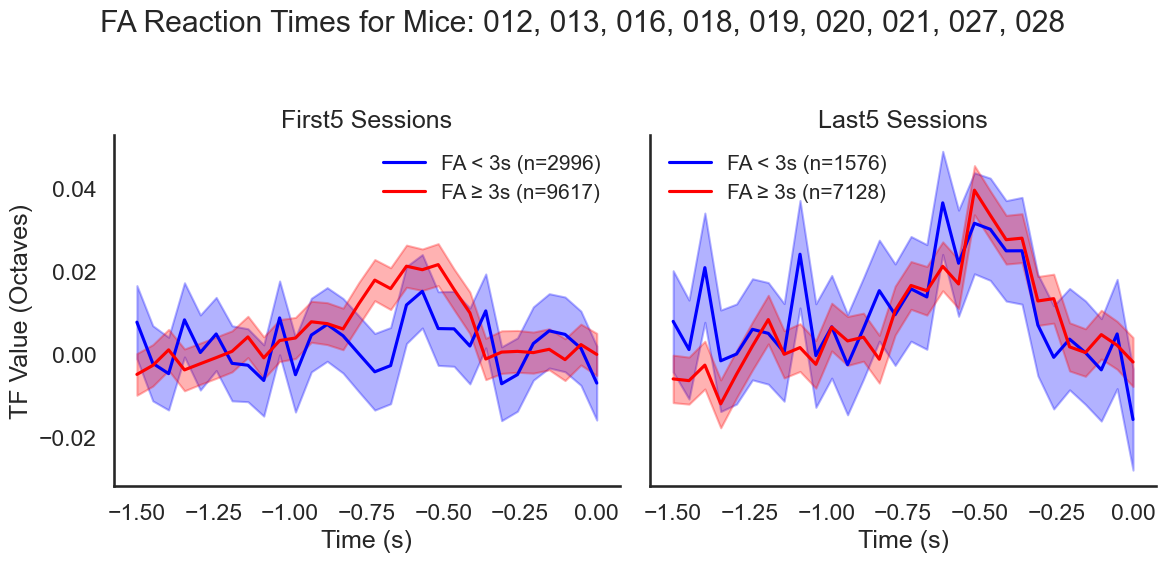

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='white')
sns.set_context('talk', font_scale=1.0)

# Define the subject groups based on mouse_id
subject_groups = [
    ['012', '013', '016', '018', '019', '020', '021', '027', '028']
    # Add more groups if needed
]

# Define reaction time thresholds
rt_threshold =3
min_rt = 0.5  # Minimum reaction time after baseline onset

# Step 1: Loop through the subject groups
for group in subject_groups:
    # Initialize dictionaries to hold windows for session subsets
    windows_data = {
        'first5_early': [],
        'first5_late': [],
        'last5_early': [],
        'last5_late': []
    }

    # Filter the DataFrame for the current group of mouse_ids
    group_df = all_mice_behavior_only_df[all_mice_behavior_only_df['mouse_id'].isin(group)]

    # Loop through each mouse in the group
    for mouse in group:
        mouse_df = group_df[group_df['mouse_id'] == mouse]

        # Get unique session identifiers sorted chronologically
        sessions = sorted(mouse_df['session_timestamp'].dropna().unique())

        # Select first 5 and last 5 sessions
        first5_sessions = sessions[:5]
        last5_sessions = sessions[-5:]
        # last5_sessions = hp2.expert_state(mouse_df, num_sessions = 5)

        # Function to process sessions
        def process_sessions(session_list, window_key_prefix):
            for session in session_list:
                session_df = mouse_df[mouse_df['session_timestamp'] == session]

                # Step 2: Subset for the trials where the outcome was 'FA' and reaction_times >= min_rt
                fa_df = session_df[
                    (session_df['outcomes'] == 'FA') & 
                    (session_df['reaction_times'] >= min_rt)
                ]
                if fa_df.empty:
                    continue

                # Ensure 'TF_vectors' column exists
                if 'TF_vectors' in fa_df.columns:
                    tf_vectors = fa_df['TF_vectors'].tolist()
                else:
                    print("Error: 'TF_vectors' column not found.")
                    continue

                # Step 3: For each trial, extract the TF vector window
                expected_window_size = 30  # 1.5 seconds with 50ms per bin

                for rt, tf_vector in zip(fa_df['reaction_times'], tf_vectors):
                    # Ensure tf_vector is a numpy array
                    tf_vector = np.array(tf_vector)

                    # Calculate bins such that we always get a window size of 1.5 seconds
                    start_bin = max(0, int(np.floor((rt - 1.5) * 20)))  # 50ms bins => 20 bins per second
                    end_bin = start_bin + expected_window_size  # Ensure window size

                    window = np.log2(tf_vector[start_bin:end_bin])

                    if len(window) == expected_window_size:
                        if rt < rt_threshold:
                            windows_data[f'{window_key_prefix}_early'].append(window)
                        elif rt >= rt_threshold+1:
                            windows_data[f'{window_key_prefix}_late'].append(window)
                    else:
                        print(f"Warning: unexpected window size for trial {rt}, the bin window size is {len(window)}")

        # Process first 5 sessions
        process_sessions(first5_sessions, 'first5')

        # Process last 5 sessions
        process_sessions(last5_sessions, 'last5')

    # Step 4: Create combined plots with event counts
    fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    time_points = np.linspace(-1.5, 0, 30)  # Ensure time_points has 30 points
    rt_labels = {'early': 'FA < 3s', 'late': 'FA ≥ 3s'}
    colors = {'early': 'blue', 'late': 'red'}

    for idx, session_subset in enumerate(['first5', 'last5']):
        for rt_category in ['early', 'late']:
            key = f'{session_subset}_{rt_category}'
            event_count = len(windows_data[key])
            
            # Print the number of events for each line
            print(f"Number of events for {session_subset.capitalize()} Sessions, {rt_labels[rt_category]}: {event_count}")
            
            if windows_data[key]:
                mean = np.mean(windows_data[key], axis=0)
                ci95 = 1.96 * np.std(windows_data[key], axis=0) / np.sqrt(event_count)
                # Include event count in the legend label
                rt_label = f"{rt_labels[rt_category]} (n={event_count})"
                axs[idx].plot(time_points, mean, label=rt_label, color=colors[rt_category])
                axs[idx].fill_between(time_points, mean - ci95, mean + ci95, color=colors[rt_category], alpha=0.3)

        # axs[idx].axvline(x=-0.5, color='gray', linestyle='--', label='0.5s Threshold')
        axs[idx].set_title(f"{session_subset.capitalize()} Sessions")
        axs[idx].set_xlabel('Time (s)')
        if idx == 0:
            axs[idx].set_ylabel('TF Value (Octaves)')
        axs[idx].legend(fontsize='small', frameon = False)

    plt.suptitle(f"FA Reaction Times for Mice: {', '.join(group)}")
    sns.despine()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


### OUTCOME SEQUENCE

In [ ]:
def plot_outcome_sequence(session_data):
    # Extract outcomes from session_data
    outcomes = session_data['outcomes']
    
    
    # Create a DataFrame suitable for seaborn
    outcome_df = pd.DataFrame({
        'Trial': range(len(outcomes)),
        'Outcome': outcomes
    })
    
    # Create the plot
    # plt.figure(figsize=(10, 2))
    sns.scatterplot(data=outcome_df, x='Trial', y='Outcome', hue='Outcome', palette=outcome_palette, marker='|', s=200, alpha=0.7, hue_order=outcome_order)
    
    # Customize the plot
    plt.xlabel('Trial Number')
    plt.ylabel('Outcome')
    plt.title('Sequence of Outcomes')
    plt.yticks([])  # Hide y-axis ticks
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1), frameon=False, fontsize='small')
    sns.despine()
    # plt.show()

### FREQUENCY AND FRACTION OF EACH OUTCOME

In [ ]:
def plot_outcome_distribution(ax, session_data, outcome_palette):
    # Extract outcomes from session_data
    outcomes = session_data['outcomes']
    
    # Create a DataFrame of outcome counts
    outcome_counts = outcomes.value_counts().reset_index()
    outcome_counts.columns = ['Outcome', 'Frequency']
    
    # Calculate the fraction of each outcome
    outcome_counts['Fraction'] = outcome_counts['Frequency'] / outcome_counts['Frequency'].sum()
    ax.set_title('Frequency and Fraction of Each Outcome')
    # Plot the frequency
    sns.barplot(data=outcome_counts, x='Outcome', y='Frequency', palette=outcome_palette, ax=ax, hue_order=outcome_order)
    
    
    
    # Create a second y-axis for the fraction
    ax2 = ax.twinx()
    
    # Plot the fraction with a secondary y-axis
    sns.barplot(data=outcome_counts, x='Outcome', y='Fraction', ax=ax2, alpha=0)
    
    # Hide the top spines
    ax.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(True)
    # plt.show()

### PERFORMANCE

In [ ]:
def plot_session_performance(session_data):
    # Calculate session performance for laser on and laser off trials
    perf_laser_on = ph.calculate_session_performance(session_data[session_data['laser_states'] == 1])
    perf_laser_off = ph.calculate_session_performance(session_data[session_data['laser_states'] == 0])

    # Create DataFrames
    perf_laser_on_df = pd.DataFrame.from_dict(perf_laser_on, orient='index', columns=['performance', 'ci95'])
    perf_laser_off_df = pd.DataFrame.from_dict(perf_laser_off, orient='index', columns=['performance', 'ci95'])

    # Create the point plot
    sns.pointplot(x=perf_laser_on_df.index, y='performance', data=perf_laser_on_df, color='blue', label='Laser On')
    sns.pointplot(x=perf_laser_off_df.index, y='performance', data=perf_laser_off_df,color = 'gray', label='Laser Off')

    # Add error bars
    plt.errorbar(x=perf_laser_on_df.index.astype('str'), y=perf_laser_on_df['performance'], yerr=perf_laser_on_df['ci95'], capsize=3)
    plt.errorbar(x=perf_laser_off_df.index.astype('str'), y=perf_laser_off_df['performance'], yerr=perf_laser_off_df['ci95'], capsize=3, color='gray')

    # Customize the plot
    sns.despine()
    plt.xlabel('Change Size (TF)')
    plt.ylabel('Performance')
    plt.title(f'Performance by Change Size') # mouse: BG_{session_data["mouse_id"].iloc[0]}')
    plt.legend()
    # plt.tight_layout(pad=2.0)
    plt.show()

In [ ]:
plot_session_performance(session_data)

### HIT REACTION TIMES BY CHANGE SIZE

In [ ]:
def plot_hit_change_size_reaction_times(session_data):
    # Filter the DataFrame for 'Hit' outcomes
    hit_df = session_data[session_data['outcomes'] == 'Hit']
    
    # Create the point plot
    sns.pointplot(x='change_sizes_TF', y='reaction_times', data=hit_df, hue='laser_states',palette= laser_palette, errorbar=('ci', 95), capsize=0.15,errwidth=1.5)
    
    
    # Customize the plot
    plt.xlabel('Change Size (TF)')
    plt.ylabel('Reaction Time (s)')
    plt.title('Reaction Times by Change Size')
    sns.despine()
    plt.show()

In [ ]:
plot_hit_change_size_reaction_times(session_data)

### CUMULATIVE FRACTION OF EACH OUTCOME

In [ ]:
def plot_cumulative_outcome_curve(session_data, outcome_palette):
    handles = []
    for outcome in outcome_order:
        outcome_df = session_data[session_data['outcomes'] == outcome]
        laser_true_df = outcome_df[outcome_df['laser_states'] == True]
        laser_false_df = outcome_df[outcome_df['laser_states'] == False]
        
        true_line = sns.ecdfplot(data=laser_true_df, x=laser_true_df.index, color=outcome_palette[outcome], alpha=0.7, linestyle='-')
        false_line = sns.ecdfplot(data=laser_false_df, x=laser_false_df.index, color=outcome_palette[outcome], alpha=0.7, linestyle='--')
        
        # Create a custom legend handle
        handle = plt.Line2D([0], [0], color=outcome_palette[outcome], label=outcome, linestyle='-')
        handle_dashed = plt.Line2D([0], [0], color=outcome_palette[outcome], label=f'{outcome} (Laser Off)', linestyle='--')
        handles.append(handle)
        handles.append(handle_dashed)
    
    plt.title('Outcomes cumulative curves')
    plt.xlabel('Trial Number')
    plt.ylabel('Cumulative Fraction')
    plt.legend(handles=handles, loc='upper left', fontsize='x-small', frameon=False)
    sns.despine()
    plt.show()

In [ ]:
plot_cumulative_outcome_curve(session_data, outcome_palette)

### CUMULATIVE FRACTION HITS or MISSES ENCOUNTERED FOR DIFFERENT CHANGE TIMES

In [ ]:
def plot_hit_change_encountered_ecdf(session_data, outcome_palette):
    # Filter the DataFrame for 'Hit' and 'Miss' outcomes
    hit_df = session_data[session_data['outcomes'] == 'Hit']
    unique_change_sizes = len(hit_df['change_sizes_TF'].unique())
    palette = sns.color_palette("magma", unique_change_sizes)
    # Create the ECDF plot
    sns.ecdfplot(x='change_times', data=hit_df, hue='change_sizes_TF', palette=palette, alpha=0.7)
    sns.ecdfplot(x='change_times', data=session_data, hue='change_sizes_TF',palette=palette, linestyle='--', alpha=0.7)
    
    # Customize the plot
    plt.xlabel('Change Time (s)')
    sns.despine()
    sns.move_legend(plt.gca(), loc = 'upper right',bbox_to_anchor=(1.2, 1),fontsize = 'x-small', frameon=False, title = '')
    plt.title('Hit change times encountered')

In [ ]:
plot_hit_change_encountered_ecdf(session_data, outcome_palette)

### Show the ecdf for change sizes encountered for hits, compared to the potential changes that could be encountered for different change sizes in the session

In [ ]:
def plot_change_encountered_ecdf(session_data, outcome_palette):
    # Filter the DataFrame for 'Hit' and 'Miss' outcomes
    change_encountered_df = session_data[(session_data['outcomes'] == 'Hit') | (session_data['outcomes'] == 'Miss')]
    
    # Create the ECDF plot
    sns.ecdfplot(x='change_times', data=change_encountered_df, hue='outcomes', palette=outcome_palette, alpha=0.7, hue_order=outcome_order)
    sns.ecdfplot(x='change_times', data=session_data, color='black', linestyle='--', alpha=0.5)
    
    # Customize the plot
    plt.xlabel('Change Time (s)')
    sns.despine()
    sns.move_legend(plt.gca(), loc = 'upper right',bbox_to_anchor=(1.2, 1),fontsize = 'x-small', frameon=False, title = '')
    plt.title('Change times encountered')
    # plt.legend(labels=['Hit', 'Miss'], loc='upper right', bbox_to_anchor=(1.2, 1), frameon=False, fontsize='x-small')
    # plt.show()

In [ ]:
def plot_change_encountered_ecdf(session_data, outcome_palette):
    # Filter the DataFrame for 'Hit' and 'Miss' outcomes
    change_encountered_df = session_data[(session_data['outcomes'] == 'Hit') | (session_data['outcomes'] == 'Miss')]
    
    # Separate the data based on laser states
    laser_on_df = change_encountered_df[change_encountered_df['laser_states'] ==True]
    laser_off_df = change_encountered_df[change_encountered_df['laser_states'] == False]
    
    # Create the ECDF plots for laser on and off trials
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    sns.ecdfplot(x='change_times', data=laser_on_df, hue='outcomes', palette=outcome_palette, alpha=0.7, hue_order=outcome_order)
    sns.ecdfplot(x='change_times', data=laser_on_df, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Change Time (s)')
    plt.title('Change times encountered (Laser On)')
    sns.despine()
    sns.move_legend(plt.gca(), loc='upper right', bbox_to_anchor=(1.2, 1), fontsize='x-small', frameon=False, title='')
    
    plt.subplot(1, 2, 2)
    sns.ecdfplot(x='change_times', data=laser_off_df, hue='outcomes', palette=outcome_palette, alpha=0.7, hue_order=outcome_order)
    sns.ecdfplot(x='change_times', data=laser_off_df, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Change Time (s)')
    plt.title('Change times encountered (Laser Off)')
    sns.despine()
    sns.move_legend(plt.gca(), loc='upper right', bbox_to_anchor=(1.2, 1), fontsize='x-small', frameon=False, title='')
    
    plt.tight_layout()
    plt.show()

In [ ]:
plot_change_encountered_ecdf(session_data, outcome_palette)

### HIT REACTION TIMES BY CHANGE SIZE AS A FUNCTION OF TRIAL PROGRESSION

In [ ]:
def plot_session_progession_hit_reaction_time(session_data, bin_size=50):
    # Filter the DataFrame for 'Hit' outcomes
    hit_df = session_data[session_data['outcomes'] == 'Hit'].copy()
    
    # Use the DataFrame index as 'trial_progression'
    hit_df['trial_progression'] = hit_df.index
    
    # Create bins for trial_progression
    hit_df['trial_bin'] = hit_df['trial_progression'] // bin_size
    
    # Calculate the midpoint of each bin
    hit_df['bin_midpoint'] = hit_df['trial_bin'] * bin_size + bin_size / 2
    
    # Group by bin_midpoint and change_sizes_TF and compute mean and standard error
    bin_stats = hit_df.groupby(['bin_midpoint', 'change_sizes_TF'])['reaction_times'].agg(['mean', 'sem']).reset_index()
    
    # Create a custom color palette using magma colormap
    unique_change_sizes = len(hit_df['change_sizes_TF'].unique())
    palette = sns.color_palette("magma", unique_change_sizes)
    
    # Plot using sns.lineplot
    # plt.figure(figsize=(8, 4))
    sns.lineplot(data=bin_stats, x='bin_midpoint', y='mean', hue='change_sizes_TF', palette=palette, marker='o',errorbar=('ci',95), err_style='bars')
    
    # Customize the plot
    plt.title('Hit Reaction Time vs. Trial Progression')
    plt.xlabel('Session progression (Trial Number)')
    plt.ylabel('Mean Reaction Time')
    plt.legend(title='Change Sizes', loc='upper right', bbox_to_anchor=(1.5, 1), frameon=False, fontsize='x-small')
    sns.despine()
    # plt.tight_layout()
    # plt.show()

In [ ]:
plot_session_progession_hit_reaction_time(session_data, bin_size=50)

### FA REACTION TIMES BY CHANGE SIZE AS A FUNCTION OF TRIAL PROGRESSION

In [ ]:
def plot_session_progession_fa_reaction_time(session_data, bin_size=50):
    # Filter the DataFrame for 'FA' outcomes
    fa_df = session_data[session_data['outcomes'] == 'FA'].copy()
    fa_df = fa_df[fa_df['reaction_times'] > 3]
    # Use the DataFrame index as 'trial_progression'
    fa_df['trial_progression'] = fa_df.index
    
    # Create bins for trial_progression
    fa_df['trial_bin'] = fa_df['trial_progression'] // bin_size
    
    # Calculate the midpoint of each bin
    fa_df['bin_midpoint'] = fa_df['trial_bin'] * bin_size + bin_size / 2
    
    # Group by bin_midpoint and change_sizes_TF and compute mean and standard error
    bin_stats = fa_df.groupby(['bin_midpoint', 'change_sizes_TF'])['reaction_times'].agg(['mean', 'sem']).reset_index()
    
    # Create a custom color palette using magma colormap
    unique_change_sizes = len(fa_df['change_sizes_TF'].unique())
    palette = sns.color_palette("magma", unique_change_sizes)
    
    # Plot using sns.lineplot
    # plt.figure(figsize=(8, 4))
    sns.lineplot(data=bin_stats, x='bin_midpoint', y='mean',marker='o', err_style='bars')
    
    # Customize the plot
    plt.title('FA Reaction Time as a Function of Trial Progression')
    plt.xlabel('session progression (Trial Number)')
    plt.ylabel('Mean Reaction Time')
    sns.despine()
    # plt.tight_layout()
    # plt.show()

In [ ]:
plot_session_progession_fa_reaction_time(session_data, bin_size=50)

### HIT TIME DISTRIBUTION FOR DIFFERENT CHANGE SIZES

In [ ]:
def plot_hit_time_distributions(session_data):
    hit_df = session_data[session_data['outcomes'] == 'Hit']
    # Create a custom color palette using magma colormap
    unique_change_sizes = len(hit_df['change_sizes_TF'].unique())
    palette = sns.color_palette("magma", unique_change_sizes)
    sns.kdeplot(data=hit_df, x='reaction_times', hue = 'change_sizes_TF', palette=palette,  fill = True, alpha = 0.2, bw_adjust = 1.0)#, height = 5, aspect = 1.5)
    plt.xlim(0,2.15)
    plt.xlabel('Reaction Time (s)')
    plt.title('Hit Reaction Time Distribution')
    sns.move_legend(plt.gca(), loc = 'upper right',bbox_to_anchor=(1, 1),fontsize = 'x-small', frameon=False, title = 'Change Sizes')
    sns.despine()
    # plt.show()

### ORGANIZE PLOTS IN A GRID (and save figure in cwd folder)

In [ ]:
def plot_session_behavior_screen(session_data, outcome_palette):    
    mouse_id = 'BG_' + session_data['mouse_id'][0]
    session_timestamp = session_data['session_date'][0]
    from matplotlib.gridspec import GridSpec
    from matplotlib.backends.backend_pdf import PdfPages
    ### PAGE 1 OF FIGURE (AND EXPORTED .pdf)
    # Create a larger figure with multiple subplots
    fig = plt.figure(figsize=(8.27, 11.69))  # A4 size in inches (8.27 x 11.69)
    gs = GridSpec(4, 2, figure=fig)



    ax1 = fig.add_subplot(gs[0,:])
    ax2 = fig.add_subplot(gs[1,0])
    ax3 = fig.add_subplot(gs[1,1])
    ax4 = fig.add_subplot(gs[2,0])
    ax5  =fig.add_subplot(gs[2,1])
    ax6 = fig.add_subplot(gs[3,0])
    ax7 = fig.add_subplot(gs[3,1])

    # plot into the grid of page 1:
    plt.sca(ax1)
    plot_outcome_sequence(session_data)
    plt.sca(ax2)
    plot_outcome_distribution(ax2,session_data, outcome_palette)
    plt.sca(ax3)
    plot_cumulative_outcome_curve(session_data, outcome_palette)
    plt.sca(ax4)
    plot_change_encountered_ecdf(session_data, outcome_palette)
    plt.sca(ax5)
    plot_session_performance(session_data)
    plt.sca(ax6)
    plot_session_progession_hit_reaction_time(session_data)
    plt.sca(ax7)
    plot_hit_change_size_reaction_times(session_data)

    fig2 = plt.figure(figsize=(8.27, 11.69))  # A4 size in inches (8.27 x 11.69)
    gs_2 = GridSpec(4, 2, figure=fig2)

    ax8 = fig2.add_subplot(gs_2[0,0])
    ax9 = fig2.add_subplot(gs_2[0,1])
    ax10 = fig2.add_subplot(gs_2[1,0])
    ax11 = fig2.add_subplot(gs_2[1,1])
    ax12 = fig2.add_subplot(gs_2[2,0])
    ax13 = fig2.add_subplot(gs_2[2,1])
    ax14 = fig2.add_subplot(gs_2[3,0])
    ax15 = fig2.add_subplot(gs_2[3,1])

    # plot into the grid of page 2:
    plt.sca(ax8)
    plot_hit_time_distributions(session_data)
    plt.sca(ax9)
    plot_session_progession_fa_reaction_time(session_data, bin_size=100)

    fig.suptitle(f'Session behvior screen for {mouse_id} on {session_timestamp}')
    # Adjust layout to fit everything nicely
    fig.tight_layout() #(pad = 2.0)
    # fig.subplots_adjust(hspace=0.3)
    fig2.tight_layout() #(pad = 2.0)

    # Save or display the figure
    with PdfPages(f'session_behvior_screen_mouse_{mouse_id}_{session_timestamp}.pdf') as pdf:
        pdf.savefig(fig)
        pdf.savefig(fig2)

    plt.show()  # Display the figure
    
# Example usage:
plot_session_behavior_screen(session_data, outcome_palette)